In [1]:
"""
NBA Movement Data - Exploratory Data Analysis
Usage: python explore_data.py <path_to_data_dir>
Example: python explore_data.py ./sample_data/nba_movement_data
"""
import sys
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [2]:
DATA_DIR = "data"
# --- flat CSVs ---
games        = pd.read_csv(os.path.join(DATA_DIR, "games.csv"))
players      = pd.read_csv(os.path.join(DATA_DIR, "players.csv"))
teams        = pd.read_csv(os.path.join(DATA_DIR, "teams.csv"))
minutes      = pd.read_csv(os.path.join(DATA_DIR, "minutes_played.csv"))

event_files  = glob.glob(os.path.join(DATA_DIR, "events", "*.csv"))
events       = pd.concat([pd.read_csv(f) for f in event_files], ignore_index=True)

moment_files = glob.glob(os.path.join(DATA_DIR, "moments", "*.csv"))
moments      = pd.concat([pd.read_csv(f) for f in moment_files], ignore_index=True)

In [ ]:
games.head()

In [ ]:
players.head()

In [ ]:
teams.head()

In [ ]:
minutes.head()

In [ ]:
events.head()

In [ ]:
moments.head()

In [ ]:
moments.describe()

In [3]:
# ─────────────────────────────────────────────────────────────
# HELPER
# ─────────────────────────────────────────────────────────────
def basic_info(df, name):
    print(f"{'='*55}")
    print(f"  {name}  —  {df.shape[0]:,} rows  x  {df.shape[1]} cols")
    print(f"{'='*55}")

    summary = pd.DataFrame({
        "dtype"    : df.dtypes,
        "non_null" : df.notnull().sum(),
        "null"     : df.isnull().sum(),
        "null_%"   : (df.isnull().mean() * 100).round(1),
        "nunique"  : df.nunique(),
        "sample"   : [df[c].dropna().iloc[0] if df[c].notnull().any() else None for c in df.columns],
    })
    display(summary)

In [4]:
basic_info(games, "games")

print("\n  First 3 rows:")
display(games.head(3))

print(f"\n  Duplicate game_id rows: {games.duplicated('GAME_ID').sum()}")
print(f"  Unique game_ids: {games['GAME_ID'].nunique()}")


  games  —  25,796 rows  x  21 cols


,dtype,non_null,null,null_%,nunique,sample
GAME_DATE_EST,str,25796,0,0.0,4149,2022-03-12
GAME_ID,int64,25796,0,0.0,25767,22101005
GAME_STATUS_TEXT,str,25796,0,0.0,1,Final
HOME_TEAM_ID,int64,25796,0,0.0,30,1610612748
VISITOR_TEAM_ID,int64,25796,0,0.0,30,1610612750
SEASON,int64,25796,0,0.0,19,2021
TEAM_ID_home,int64,25796,0,0.0,30,1610612748
PTS_home,float64,25697,99,0.4,100,104.0
FG_PCT_home,float64,25697,99,0.4,399,0.398
FT_PCT_home,float64,25697,99,0.4,403,0.76



  First 3 rows:


,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,...,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS
0,2022-03-12,22101005,Final,1610612748,1610612750,2021,1610612748,104.0,0.398,0.760,...,23.0,53.0,1610612750,113.0,0.422,0.875,0.357,21.0,46.0,0
1,2022-03-12,22101006,Final,1610612741,1610612739,2021,1610612741,101.0,0.443,0.933,...,20.0,46.0,1610612739,91.0,0.419,0.824,0.208,19.0,40.0,1
2,2022-03-12,22101007,Final,1610612759,1610612754,2021,1610612759,108.0,0.412,0.813,...,28.0,52.0,1610612754,119.0,0.489,1.000,0.389,23.0,47.0,0



  Duplicate game_id rows: 29
  Unique game_ids: 25767


In [32]:
basic_info(players, "players")

print("\n  First 3 rows:")
display(players.head(3))

print(f"\n  Duplicate player_id rows: {players.duplicated('PLAYER_ID').sum()}")


  players  —  7,228 rows  x  4 cols


,dtype,non_null,null,null_%,nunique,sample
PLAYER_NAME,str,7228,0,0.0,1749,Royce O'Neale
TEAM_ID,int64,7228,0,0.0,30,1610612762
PLAYER_ID,int64,7228,0,0.0,1769,1626220
SEASON,int64,7228,0,0.0,11,2019



  First 3 rows:


,PLAYER_NAME,TEAM_ID,PLAYER_ID,SEASON
0,Royce O'Neale,1610612762,1626220,2019
1,Bojan Bogdanovic,1610612762,202711,2019
2,Rudy Gobert,1610612762,203497,2019



  Duplicate player_id rows: 5459


In [5]:
basic_info(teams, "teams")
display(teams)  # small enough to show all


  teams  —  30 rows  x  14 cols


,dtype,non_null,null,null_%,nunique,sample
LEAGUE_ID,int64,30,0,0.0,1,0
TEAM_ID,int64,30,0,0.0,30,1610612737
MIN_YEAR,int64,30,0,0.0,15,1949
MAX_YEAR,int64,30,0,0.0,1,2019
ABBREVIATION,str,30,0,0.0,30,ATL
NICKNAME,str,30,0,0.0,30,Hawks
YEARFOUNDED,int64,30,0,0.0,15,1949
CITY,str,30,0,0.0,29,Atlanta
ARENA,str,30,0,0.0,29,State Farm Arena
ARENACAPACITY,float64,26,4,13.3,24,18729.0


,LEAGUE_ID,TEAM_ID,MIN_YEAR,MAX_YEAR,ABBREVIATION,NICKNAME,YEARFOUNDED,CITY,ARENA,ARENACAPACITY,OWNER,GENERALMANAGER,HEADCOACH,DLEAGUEAFFILIATION
0,0,1610612737,1949,2019,ATL,Hawks,1949,Atlanta,State Farm Arena,18729.0,Tony Ressler,Travis Schlenk,Lloyd Pierce,Erie Bayhawks
1,0,1610612738,1946,2019,BOS,Celtics,1946,Boston,TD Garden,18624.0,Wyc Grousbeck,Danny Ainge,Brad Stevens,Maine Red Claws
2,0,1610612740,2002,2019,NOP,Pelicans,2002,New Orleans,Smoothie King Center,NaN,Tom Benson,Trajan Langdon,Alvin Gentry,No Affiliate
3,0,1610612741,1966,2019,CHI,Bulls,1966,Chicago,United Center,21711.0,Jerry Reinsdorf,Gar Forman,Jim Boylen,Windy City Bulls
4,0,1610612742,1980,2019,DAL,Mavericks,1980,Dallas,American Airlines Center,19200.0,Mark Cuban,Donnie Nelson,Rick Carlisle,Texas Legends
5,0,1610612743,1976,2019,DEN,Nuggets,1976,Denver,Pepsi Center,19099.0,Stan Kroenke,Tim Connelly,Michael Malone,No Affiliate
6,0,1610612745,1967,2019,HOU,Rockets,1967,Houston,Toyota Center,18104.0,Tilman Fertitta,Daryl Morey,Mike D'Antoni,Rio Grande Valley Vipers
7,0,1610612746,1970,2019,LAC,Clippers,1970,Los Angeles,Staples Center,19060.0,Steve Ballmer,Michael Winger,Doc Rivers,Agua Caliente Clippers of Ontario
8,0,1610612747,1948,2019,LAL,Lakers,1948,Los Angeles,Staples Center,19060.0,Jerry Buss Family Trust,Rob Pelinka,Frank Vogel,South Bay Lakers
9,0,1610612748,1988,2019,MIA,Heat,1988,Miami,AmericanAirlines Arena,19600.0,Micky Arison,Pat Riley,Erik Spoelstra,Sioux Falls Skyforce


In [ ]:
basic_info(minutes, "minutes_played")

print("\n  First 3 rows:")
display(minutes.head(3))

  minutes_played  —  2,159 rows  x  3 cols


,dtype,non_null,null,null_%,nunique,sample
GAME_ID,int64,2159,0,0.0,84,21500659.0
PLAYER_ID,int64,2159,0,0.0,426,203503.0
SEC,float64,1839,320,14.8,1299,1552.0



  First 3 rows:


,GAME_ID,PLAYER_ID,SEC
0,21500659,203503,1552.0
1,21500659,201959,1727.0
2,21500659,2200,1983.0


IndexError: list index out of range

In [6]:
basic_info(events, "events")

print("\n  First 3 rows:")
display(events.head(3))

print("\n  EVENTMSGTYPE distribution:")
display(events["EVENTMSGTYPE"].value_counts().rename_axis("type").reset_index(name="count"))


  events  —  469 rows  x  33 cols


,dtype,non_null,null,null_%,nunique,sample
GAME_ID,int64,469,0,0.0,1,21500548
EVENTNUM,int64,469,0,0.0,469,0
EVENTMSGTYPE,int64,469,0,0.0,13,12
EVENTMSGACTIONTYPE,int64,469,0,0.0,40,0
PERIOD,int64,469,0,0.0,4,1
WCTIMESTRING,str,469,0,0.0,92,10:12 PM
PCTIMESTRING,str,469,0,0.0,261,12:00
HOMEDESCRIPTION,str,251,218,46.5,236,Jump Ball Plumlee vs. Bogut: Tip to Green
NEUTRALDESCRIPTION,float64,0,469,100.0,0,None
VISITORDESCRIPTION,str,234,235,50.1,219,MISS Thompson 15' Turnaround Fadeaway Shot



  First 3 rows:


,GAME_ID,EVENTNUM,EVENTMSGTYPE,EVENTMSGACTIONTYPE,PERIOD,WCTIMESTRING,PCTIMESTRING,HOMEDESCRIPTION,NEUTRALDESCRIPTION,VISITORDESCRIPTION,...,PLAYER2_TEAM_CITY,PLAYER2_TEAM_NICKNAME,PLAYER2_TEAM_ABBREVIATION,PERSON3TYPE,PLAYER3_ID,PLAYER3_NAME,PLAYER3_TEAM_ID,PLAYER3_TEAM_CITY,PLAYER3_TEAM_NICKNAME,PLAYER3_TEAM_ABBREVIATION
0,21500548,0,12,0,1,10:12 PM,12:00,NaN,NaN,NaN,...,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN
1,21500548,1,10,0,1,10:13 PM,12:00,Jump Ball Plumlee vs. Bogut: Tip to Green,NaN,NaN,...,Golden State,Warriors,GSW,5,203110,Draymond Green,1.610613e+09,Golden State,Warriors,GSW
2,21500548,2,2,86,1,10:13 PM,11:49,NaN,NaN,MISS Thompson 15' Turnaround Fadeaway Shot,...,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN



  EVENTMSGTYPE distribution:


,type,count
0,4,110
1,2,99
2,1,84
3,3,49
4,8,42
5,6,37
6,5,24
7,9,11
8,12,4
9,13,4


  moments  —  2,303,443 rows  x  10 cols


,dtype,non_null,null,null_%,nunique,sample
team_id,int64,2303443,0,0.0,3,-1.000000e+00
player_id,int64,2303443,0,0.0,24,-1.000000e+00
x_loc,float64,2303443,0,0.0,869104,4.722664e+01
y_loc,float64,2303443,0,0.0,825622,3.085514e+01
radius,float64,2303443,0,0.0,78648,4.139880e+00
game_clock,float64,2303443,0,0.0,47449,7.142800e+02
shot_clock,float64,2121192,182251,7.9,2313,1.737000e+01
quarter,int64,2303443,0,0.0,4,1.000000e+00
game_id,int64,2303443,0,0.0,1,2.150055e+07
event_id,int64,2303443,0,0.0,462,1.000000e+00



  First 3 rows:


,team_id,player_id,x_loc,y_loc,radius,game_clock,shot_clock,quarter,game_id,event_id
0,-1,-1,47.22664,30.85514,4.13988,714.28,17.37,1,21500548,1
1,1610612757,202329,84.50010,35.83146,0.00000,714.28,17.37,1,21500548,1
2,1610612757,203081,61.12241,28.57199,0.00000,714.28,17.37,1,21500548,1


  Ball rows   : 208,993
  Player rows : 2,094,450
  Other rows  : 0   ← should be 0

  Rows per timestamp — expected 11 (1 ball + 10 players):
 rows_per_ts  count
          22  26225
          11  15655
          33  14428
          44   8734
          55   3034
          66   1719
          77    859
          88    150
          10     64
          20     41
  NBA court: x in [0, 94] ft,  y in [0, 50] ft

  [ball]
    x_loc : -5.75  –  99.84   |  out-of-bounds: 5,718
    y_loc : -2.82  –  53.11   |  out-of-bounds: 2,053

  [players]
    x_loc : -7.44  –  99.13   |  out-of-bounds: 13,124
    y_loc : -3.09  –  51.98   |  out-of-bounds: 5,787

  game_clock  (expected 0 – 720 per quarter):
    range  : 0.00  –  718.43
    < 0    : 0
    > 720  : 0

  shot_clock  (expected 0 – 24, nullable):
    nulls  : 182,251  (7.9%)
    range  : 0.01  –  24.00
    < 0    : 0
    > 24   : 0

  quarter values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  (>4 means overtime)
  Consecutive jump 

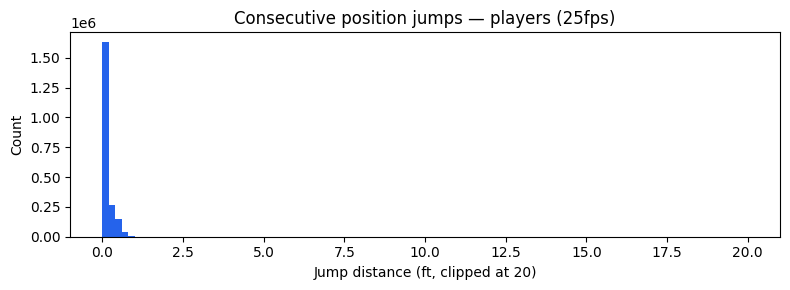

In [11]:
basic_info(moments, "moments")

print("\n  First 3 rows:")
display(moments.head(3))

# ─────────────────────────────────────────────────────────────
# CELL 7 — moments: ball vs players split
# ─────────────────────────────────────────────────────────────
ball      = moments[moments["player_id"] == -1]
players_m = moments[moments["player_id"] != -1]

print(f"  Ball rows   : {len(ball):,}")
print(f"  Player rows : {len(players_m):,}")
print(f"  Other rows  : {len(moments) - len(ball) - len(players_m):,}   ← should be 0")

# Each moment should have exactly 1 ball + 10 players = 11 rows
# Group by (game_id, quarter, game_clock) and count
moment_counts = moments.groupby(["game_id", "quarter", "game_clock"]).size()
print(f"\n  Rows per timestamp — expected 11 (1 ball + 10 players):")
print(moment_counts.value_counts().head(10).rename_axis("rows_per_ts").reset_index(name="count").to_string(index=False))


# ─────────────────────────────────────────────────────────────
# CELL 8 — moments: coordinate sanity
# ─────────────────────────────────────────────────────────────
print("  NBA court: x in [0, 94] ft,  y in [0, 50] ft\n")
for df, label in [(ball, "ball"), (players_m, "players")]:
    out_x = (df["x_loc"] < 0) | (df["x_loc"] > 94)
    out_y = (df["y_loc"] < 0) | (df["y_loc"] > 50)
    print(f"  [{label}]")
    print(f"    x_loc : {df['x_loc'].min():.2f}  –  {df['x_loc'].max():.2f}   |  out-of-bounds: {out_x.sum():,}")
    print(f"    y_loc : {df['y_loc'].min():.2f}  –  {df['y_loc'].max():.2f}   |  out-of-bounds: {out_y.sum():,}\n")

# ─────────────────────────────────────────────────────────────
# CELL 9 — moments: clock columns
# ─────────────────────────────────────────────────────────────
print("  game_clock  (expected 0 – 720 per quarter):")
print(f"    range  : {moments['game_clock'].min():.2f}  –  {moments['game_clock'].max():.2f}")
print(f"    < 0    : {(moments['game_clock'] < 0).sum():,}")
print(f"    > 720  : {(moments['game_clock'] > 720).sum():,}")

print("\n  shot_clock  (expected 0 – 24, nullable):")
print(f"    nulls  : {moments['shot_clock'].isnull().sum():,}  ({100*moments['shot_clock'].isnull().mean():.1f}%)")
sc = moments["shot_clock"].dropna()
print(f"    range  : {sc.min():.2f}  –  {sc.max():.2f}")
print(f"    < 0    : {(sc < 0).sum():,}")
print(f"    > 24   : {(sc > 24).sum():,}")

print(f"\n  quarter values: {sorted(moments['quarter'].dropna().unique().astype(int))}")
print(f"  (>4 means overtime)")


# ─────────────────────────────────────────────────────────────
# CELL 10 — moments: consecutive jump distances (teleport check)
# ─────────────────────────────────────────────────────────────
sample = players_m.sort_values(
    ["game_id", "player_id", "quarter", "game_clock"],
    ascending=[True, True, True, False]   # game_clock counts DOWN
)
sample = sample.copy()
sample["x_next"] = sample.groupby(["game_id", "player_id"])["x_loc"].shift(-1)
sample["y_next"] = sample.groupby(["game_id", "player_id"])["y_loc"].shift(-1)
sample["jump_ft"] = np.sqrt(
    (sample["x_loc"] - sample["x_next"])**2 +
    (sample["y_loc"] - sample["y_next"])**2
)

jumps = sample["jump_ft"].dropna()
print(f"  Consecutive jump distances (feet between frames at 25fps):")
print(f"    mean   : {jumps.mean():.3f}")
print(f"    median : {jumps.median():.3f}")
print(f"    95th % : {jumps.quantile(0.95):.3f}")
print(f"    max    : {jumps.max():.3f}")
print(f"    > 10ft : {(jumps > 10).sum():,}  ({100*(jumps > 10).mean():.2f}%)  ← likely substitutions/gaps")
print(f"    > 50ft : {(jumps > 50).sum():,}  ← genuine data errors")

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(jumps.clip(upper=20), bins=100, color="#2563eb", edgecolor="none")
ax.set_xlabel("Jump distance (ft, clipped at 20)")
ax.set_ylabel("Count")
ax.set_title("Consecutive position jumps — players (25fps)")
plt.tight_layout()
plt.show()



In [18]:
moment_counts = moments.groupby(["game_id", "quarter", "game_clock"]).size()
print(f"\n  Rows per timestamp — expected 11 (1 ball + 10 players):")
print(moment_counts.value_counts().head(10).rename_axis("rows_per_ts").reset_index(name="count").to_string(index=False))
moments_grouped = moments.groupby(["game_id", "quarter", "game_clock"])
moments.groupby(["game_id", "quarter", "game_clock"]).size()



  Rows per timestamp — expected 11 (1 ball + 10 players):
 rows_per_ts  count
          22  26225
          11  15655
          33  14428
          44   8734
          55   3034
          66   1719
          77    859
          88    150
          10     64
          20     41


game_id   quarter  game_clock
21500548  1        0.00          44
                   0.04          44
                   0.08          44
                   0.12          44
                   0.16          44
                                 ..
          4        718.27        11
                   718.31        11
                   718.35        11
                   718.39        11
                   718.43        11
Length: 71014, dtype: int64

In [19]:
moments.sort_values(["game_id", "quarter", "game_clock", "player_id"]).head(30)

,team_id,player_id,x_loc,y_loc,radius,game_clock,shot_clock,quarter,game_id,event_id
533405,-1,-1,89.53614,26.25488,8.2273,0.0,NaN,1,21500548,113
534318,-1,-1,89.53614,26.25488,8.2273,0.0,NaN,1,21500548,114
535231,-1,-1,89.53614,26.25488,8.2273,0.0,NaN,1,21500548,117
536144,-1,-1,89.53614,26.25488,8.2273,0.0,NaN,1,21500548,119
533412,1610612744,2733,90.17629,1.87636,0.0000,0.0,NaN,1,21500548,113
534325,1610612744,2733,90.17629,1.87636,0.0000,0.0,NaN,1,21500548,114
535238,1610612744,2733,90.17629,1.87636,0.0000,0.0,NaN,1,21500548,117
536151,1610612744,2733,90.17629,1.87636,0.0000,0.0,NaN,1,21500548,119
533411,1610612744,2738,55.51012,24.73840,0.0000,0.0,NaN,1,21500548,113
534324,1610612744,2738,55.51012,24.73840,0.0000,0.0,NaN,1,21500548,114


  moments  —  781,044 rows  x  10 cols


,dtype,non_null,null,null_%,nunique,sample
team_id,int64,781044,0,0.0,3,-1.000000e+00
player_id,int64,781044,0,0.0,24,-1.000000e+00
x_loc,float64,781044,0,0.0,744457,4.722664e+01
y_loc,float64,781044,0,0.0,714037,3.085514e+01
radius,float64,781044,0,0.0,67407,4.139880e+00
game_clock,float64,781044,0,0.0,47449,7.142800e+02
shot_clock,float64,747501,33543,4.3,2313,1.737000e+01
quarter,int64,781044,0,0.0,4,1.000000e+00
game_id,int64,781044,0,0.0,1,2.150055e+07
event_id,int64,781044,0,0.0,261,1.000000e+00



  First 3 rows:


,team_id,player_id,x_loc,y_loc,radius,game_clock,shot_clock,quarter,game_id,event_id
0,-1,-1,47.22664,30.85514,4.13988,714.28,17.37,1,21500548,1
1,1610612757,202329,84.50010,35.83146,0.00000,714.28,17.37,1,21500548,1
2,1610612757,203081,61.12241,28.57199,0.00000,714.28,17.37,1,21500548,1


  Ball rows   : 70,881
  Player rows : 710,163
  Other rows  : 0   ← should be 0

  Rows per timestamp — expected 11 (1 ball + 10 players):
 rows_per_ts  count
          11  70867
          10    133
          13      9
          12      5
  NBA court: x in [0, 94] ft,  y in [0, 50] ft

  [ball]
    x_loc : -5.40  –  99.84   |  out-of-bounds: 1,113
    y_loc : -2.82  –  53.11   |  out-of-bounds: 155

  [players]
    x_loc : -7.44  –  98.07   |  out-of-bounds: 3,331
    y_loc : -3.09  –  51.98   |  out-of-bounds: 795

  game_clock  (expected 0 – 720 per quarter):
    range  : 0.00  –  718.43
    < 0    : 0
    > 720  : 0

  shot_clock  (expected 0 – 24, nullable):
    nulls  : 33,543  (4.3%)
    range  : 0.01  –  24.00
    < 0    : 0
    > 24   : 0

  quarter values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  (>4 means overtime)
  Consecutive jump distances (feet between frames at 25fps):
    mean   : 0.358
    median : 0.221
    95th % : 0.611
    max    : 89.369
    > 10ft

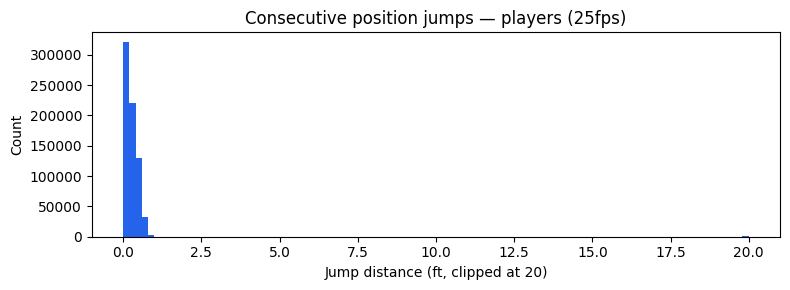

In [12]:
dropped_dups_moments = moments.drop_duplicates(
    subset=["game_id", "player_id", "quarter", "game_clock"]
)

basic_info(dropped_dups_moments, "moments")

print("\n  First 3 rows:")
display(dropped_dups_moments.head(3))

# ─────────────────────────────────────────────────────────────
# CELL 7 — moments: ball vs players split
# ─────────────────────────────────────────────────────────────
ball      = dropped_dups_moments[dropped_dups_moments["player_id"] == -1]
players_m = dropped_dups_moments[dropped_dups_moments["player_id"] != -1]

print(f"  Ball rows   : {len(ball):,}")
print(f"  Player rows : {len(players_m):,}")
print(f"  Other rows  : {len(dropped_dups_moments) - len(ball) - len(players_m):,}   ← should be 0")

# Each moment should have exactly 1 ball + 10 players = 11 rows
# Group by (game_id, quarter, game_clock) and count
moment_counts = dropped_dups_moments.groupby(["game_id", "quarter", "game_clock"]).size()
print(f"\n  Rows per timestamp — expected 11 (1 ball + 10 players):")
print(moment_counts.value_counts().head(10).rename_axis("rows_per_ts").reset_index(name="count").to_string(index=False))


# ─────────────────────────────────────────────────────────────
# CELL 8 — moments: coordinate sanity
# ─────────────────────────────────────────────────────────────
print("  NBA court: x in [0, 94] ft,  y in [0, 50] ft\n")
for df, label in [(ball, "ball"), (players_m, "players")]:
    out_x = (df["x_loc"] < 0) | (df["x_loc"] > 94)
    out_y = (df["y_loc"] < 0) | (df["y_loc"] > 50)
    print(f"  [{label}]")
    print(f"    x_loc : {df['x_loc'].min():.2f}  –  {df['x_loc'].max():.2f}   |  out-of-bounds: {out_x.sum():,}")
    print(f"    y_loc : {df['y_loc'].min():.2f}  –  {df['y_loc'].max():.2f}   |  out-of-bounds: {out_y.sum():,}\n")

# ─────────────────────────────────────────────────────────────
# CELL 9 — moments: clock columns
# ─────────────────────────────────────────────────────────────
print("  game_clock  (expected 0 – 720 per quarter):")
print(f"    range  : {dropped_dups_moments['game_clock'].min():.2f}  –  {dropped_dups_moments['game_clock'].max():.2f}")
print(f"    < 0    : {(dropped_dups_moments['game_clock'] < 0).sum():,}")
print(f"    > 720  : {(dropped_dups_moments['game_clock'] > 720).sum():,}")

print("\n  shot_clock  (expected 0 – 24, nullable):")
print(f"    nulls  : {dropped_dups_moments['shot_clock'].isnull().sum():,}  ({100*dropped_dups_moments['shot_clock'].isnull().mean():.1f}%)")
sc = dropped_dups_moments["shot_clock"].dropna()
print(f"    range  : {sc.min():.2f}  –  {sc.max():.2f}")
print(f"    < 0    : {(sc < 0).sum():,}")
print(f"    > 24   : {(sc > 24).sum():,}")

print(f"\n  quarter values: {sorted(dropped_dups_moments['quarter'].dropna().unique().astype(int))}")
print(f"  (>4 means overtime)")


# ─────────────────────────────────────────────────────────────
# CELL 10 — moments: consecutive jump distances (teleport check)
# ─────────────────────────────────────────────────────────────
sample = players_m.sort_values(
    ["game_id", "player_id", "quarter", "game_clock"],
    ascending=[True, True, True, False]   # game_clock counts DOWN
)
sample = sample.copy()
sample["x_next"] = sample.groupby(["game_id", "player_id"])["x_loc"].shift(-1)
sample["y_next"] = sample.groupby(["game_id", "player_id"])["y_loc"].shift(-1)
sample["jump_ft"] = np.sqrt(
    (sample["x_loc"] - sample["x_next"])**2 +
    (sample["y_loc"] - sample["y_next"])**2
)

jumps = sample["jump_ft"].dropna()
print(f"  Consecutive jump distances (feet between frames at 25fps):")
print(f"    mean   : {jumps.mean():.3f}")
print(f"    median : {jumps.median():.3f}")
print(f"    95th % : {jumps.quantile(0.95):.3f}")
print(f"    max    : {jumps.max():.3f}")
print(f"    > 10ft : {(jumps > 10).sum():,}  ({100*(jumps > 10).mean():.2f}%)  ← likely substitutions/gaps")
print(f"    > 50ft : {(jumps > 50).sum():,}  ← genuine data errors")

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(jumps.clip(upper=20), bins=100, color="#2563eb", edgecolor="none")
ax.set_xlabel("Jump distance (ft, clipped at 20)")
ax.set_ylabel("Count")
ax.set_title("Consecutive position jumps — players (25fps)")
plt.tight_layout()
plt.show()



In [29]:
moments.sort_values(["game_id", "quarter", "game_clock", "player_id"]).head(30)

# Drop duplicates - keep one row per player per timestamp
moments_deduped = moments.drop_duplicates(
    subset=["game_id", "player_id", "quarter", "game_clock"]
).copy()

print(f"Before dedup: {len(moments):,}")
print(f"After dedup:  {len(moments_deduped):,}")

# Filter out ball
players_m = moments_deduped[moments_deduped["player_id"] != -1].copy()

# Sort chronologically — game_clock counts DOWN so descending = forward in time
players_m = players_m.sort_values(
    ["game_id", "player_id", "quarter", "game_clock"],
    ascending=[True, True, True, False]
)

players_m.groupby(["game_id", "player_id"])['x_loc'].head(3)

Before dedup: 2,303,443
After dedup:  781,044


445137     91.07233
445148     91.06242
445159     91.04258
314907      3.76209
314918      3.78855
             ...   
2084134    22.86218
2084144    23.33792
2084126     4.60263
2084136     4.65700
2084146     4.71947
Name: x_loc, Length: 69, dtype: float64

In [ ]:
# Drop duplicates - keep one row per player per timestamp
moments_deduped = moments.drop_duplicates(
    subset=["game_id", "player_id", "quarter", "game_clock"]
).copy()

print(f"Before dedup: {len(moments):,}")
print(f"After dedup:  {len(moments_deduped):,}")

# Filter out ball
players_m = moments_deduped[moments_deduped["player_id"] != -1].copy()

# Sort chronologically — game_clock counts DOWN so descending = forward in time
players_m = players_m.sort_values(
    ["game_id", "player_id", "quarter", "game_clock"],
    ascending=[True, True, True, False]
)

# Get next position for each player within the same game
players_m["x_next"] = players_m.groupby(["game_id", "player_id"])["x_loc"].shift(-1)
players_m["y_next"] = players_m.groupby(["game_id", "player_id"])["y_loc"].shift(-1)

# Euclidean distance in feet, converted to meters
players_m["dist_m"] = np.sqrt(
    (players_m["x_loc"] - players_m["x_next"])**2 +
    (players_m["y_loc"] - players_m["y_next"])**2
) * 0.3048

# Total distance per player (across all games in the dataset)
total_distance = (
    players_m
    .groupby("player_id")["dist_m"]
    .sum()
    .reset_index()
    .rename(columns={"dist_m": "total_distance_m"})
    .sort_values("total_distance_m", ascending=False)
)

print(f"\nTotal distance per player:")
display(total_distance)


Before dedup: 2,303,443
After dedup:  781,044

Total distance per player:


,player_id,total_distance_m
17,203468,5865.508700
10,203081,5561.912182
15,203110,5504.615863
16,203459,5313.299068
9,202691,5290.645024
3,201575,4904.834452
5,201939,4338.070733
13,203090,3971.855078
11,203084,3810.629867
7,202329,3362.648427


In [24]:
# Sum seconds played across all games for each player (season total)
total_minutes = (
    minutes
    .groupby("PLAYER_ID")["SEC"]
    .sum()
    .reset_index()
    .rename(columns={"PLAYER_ID": "player_id", "SEC": "total_seconds_played"})
)

# Join total distance with total seconds played
result = total_distance.merge(total_minutes, on="player_id", how="left")

# Apply formula: TotalDistance * 12 / minutes_played
result["minutes_played"]         = result["total_seconds_played"] / 60
result["distance_per_quarter_m"] = (
    result["total_distance_m"] * 12 / result["minutes_played"]
).round(0).astype("Int64")

# Flag players with no minutes data
missing = result["total_seconds_played"].isna().sum()
print(f"Players with no entry in minutes_played: {missing} — will have NaN distance_per_quarter")

# Final output
result_final = result[["player_id", "distance_per_quarter_m"]].sort_values(
    "distance_per_quarter_m", ascending=False
)
print("\nDistance per quarter per player (meters):")
display(result_final)

Players with no entry in minutes_played: 0 — will have NaN distance_per_quarter

Distance per quarter per player (meters):


,player_id,distance_per_quarter_m
14,201945,945
1,203081,867
7,203090,866
21,1626192,855
3,203459,671
0,203468,662
15,203086,580
17,203943,575
9,202329,549
18,202334,534
